# Fracture Modeling

Dhaval Kadia, Brandon Nelson

This notebook introduces synthetic fractures, specifically *linear fractures*, see the definitions and figure below from [Cleveland Clinic](https://my.clevelandclinic.org/health/diseases/skull-fracture) for more details.

- **Linear fracture**: This is the most common type of skull fracture. It usually happens in the bone toward the top of your head, above your ears.
- **Depressed fracture**: A break in your skull that pushes part of the bone closer to your brain. A depressed fracture can involve multiple cracks and fragments.
- **Basal (basilar) fracture**: A break of the bones at the base of your skull. This includes the bones behind your face and the bones that are internal in your brain that you can’t see.
- **Diastatic fracture**: A separation of the cranial sutures, or the bands of tissue that connect the bones in your skull together.
- **Combination or complex fractures**: Fractures that may involve several of the above types or multiple areas of fractured bone.

<img src="https://my.clevelandclinic.org/-/scassets/images/org/health/articles/skull-fracture" width="300">

This notebooks describes step 1 Synthetic Data Generation of the fracture modeling subproject:

<img src="attachment:47a48d66-ca8d-4530-970e-b8ef3ff1706d.png" width="600">

## Select a starting phantom

In [32]:
%pip install -q tomli-w pyvista pyransac3d

Note: you may need to restart the kernel to use updated packages.


In [33]:
import VITools
available_phantoms = VITools.get_available_phantoms()
available_phantoms

{'0.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=0.0, phantom_dir=PosixPath('/projects01/didsr-aiml/common_data/pedsilicoich/UNC_Head_phantom')),
 '1.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=1.0, phantom_dir=PosixPath('/projects01/didsr-aiml/common_data/pedsilicoich/UNC_Head_phantom')),
 '2.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=2.0, phantom_dir=PosixPath('/projects01/didsr-aiml/common_data/pedsilicoich/UNC_Head_phantom')),
 '6.5 yr NIHPD Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.NIHPD_Head'>, age=6.5, phantom_dir=PosixPath('/projects01/didsr-aiml/common_data/pedsilicoich/NIHPD_Head_Phantom')),
 '9.0 yr NIHPD Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.NIHPD_Head'>, age=9.0, phantom_dir=PosixPath('/projects01/didsr-aiml/common_data/pedsilicoich/NIHPD_Head_Phantom')),
 '10.5 yr NIHPD He

In [34]:
phantom = available_phantoms['6.5 yr NIHPD Head']()
# phantom.add_fracture=True
# phantom.resize(3*[240]) NOTE_K: keeping original size
# phantom.insert_lesion('EDH', mass_effect=True, seed=42, intensity=80, volume=5, edema=1)

pseudo-CT images not found; defaulting to otsu segmentation method


Check that fractures work for *UNC, NIHPD, and MIDA*

It looks like this `thresh` argument is important in setting the distance of the fracture to skull. Since this threshold is used in projecting the fracture to the skull surface we should find a better way of setting this value, we could also adjust it to determine the depth of the fracture. Currently thresh is in units of pixels (since its a threshold of the distance transform). We can look into ways to make this unitless, either a fraction the head size or something like that so that it will continue to work even if the base phantom is resized.

Starting random walk fracture generation with 200 iterations
Skull centroid at: (np.float64(100.4560407962838), np.float64(125.80797964387281), np.float64(112.60381441052049))
Casting rays with random walk...
Random walk ray casting complete!


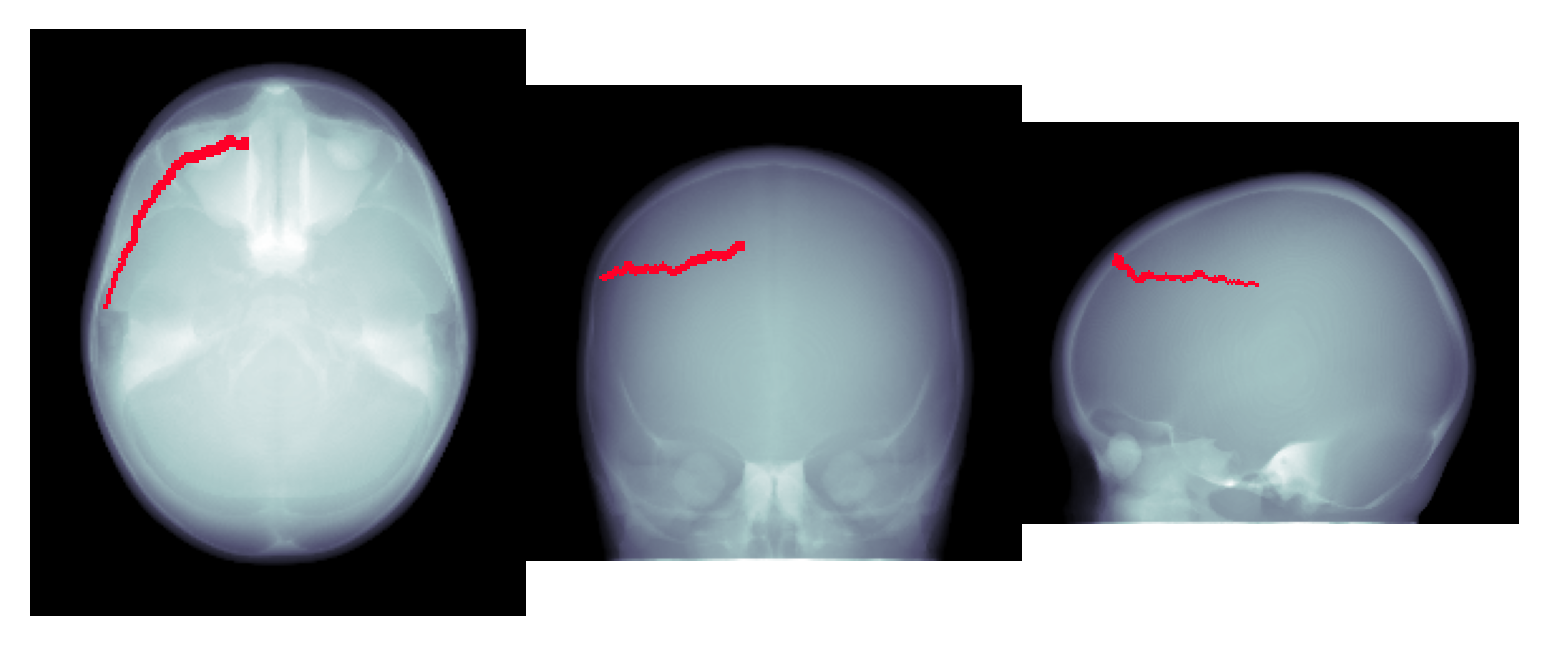

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import random
from insilicoICH.lesion_definition import FractureLesion


fracture_lesion = FractureLesion('linear fracture', boundary=phantom.get_skull_map(), spacings=phantom.spacings, seed=9)
fracture_lesion.generate(fracture_length=200)

fractures = fracture_lesion.mask
fracture_mask = np.ma.masked_where(fractures == 0, fractures)
phantom.add_fractures = False
vol = phantom.get_CT_number_phantom()

f, axs = plt.subplots(1, 3, gridspec_kw=dict(wspace=0, hspace=0), dpi=300)
for i, ax in enumerate(axs):
    ax.imshow(vol.mean(axis=i), cmap='bone')
    ax.imshow(fracture_mask.mean(axis=i), cmap='gist_rainbow', interpolation='none')
    ax.axis('off')

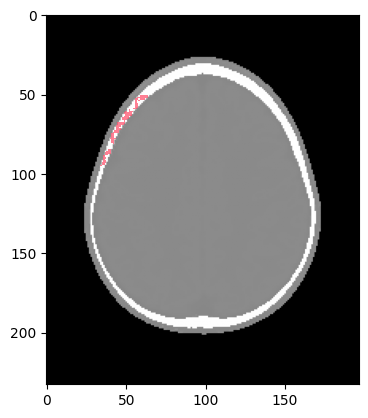

In [36]:
from skimage.measure import regionprops, label
from matplotlib import patches
c = 'g'

z_slice = fractures.mean(axis=(1,2)).argmax()
f, ax = plt.subplots()
ax.imshow(vol[z_slice], cmap='gray')
ax.imshow(fracture_mask[z_slice], cmap='gist_rainbow', interpolation='none', alpha=0.5)

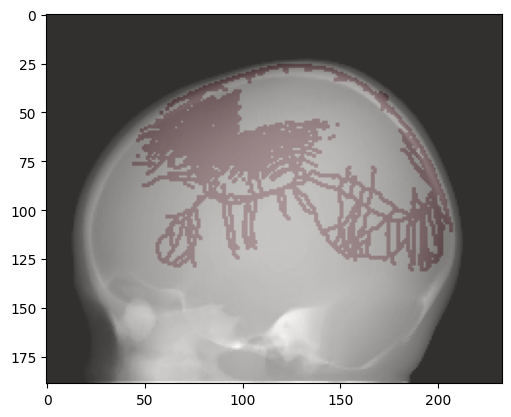

In [37]:
sutures = phantom.get_sutures()
plt.imshow(phantom.get_CT_number_phantom().mean(axis=2), cmap='gray')
plt.imshow(sutures.max(axis=2), cmap='Reds', alpha=0.2)

In [38]:
from VITools import Scanner

In [39]:
phantom.insert_lesion(fracture_lesion)


        Phantom Class: NIHPD_Head
        Age (years): 6.5
        Shape (voxels): (189, 233, 197)
        Size (mm): (151.2, 186.4, 157.6)
        
Number of lesions: 1
  - Lesion 1: linear fracture, Volume: 0.29 mL, Center: (70, 64, 56)
Mass effect strength: 0.0

In [40]:
scanner = Scanner(phantom, 'Siemens_DefinitionFlash')

Initializing Scanner object...
----------
* Calculating volume fraction maps for 4 materials and 189 slices...
* Writing volume fraction files for 4 materials and 189 slices, plus HU data...
* Writing /tmp/tmpqi4caeiv/6.5 yr NIHPD Head/phantoms/0/0_ncat_adipose_197x233x189.raw...
* Writing /tmp/tmpqi4caeiv/6.5 yr NIHPD Head/phantoms/0/0_ncat_water_197x233x189.raw...
* Writing /tmp/tmpqi4caeiv/6.5 yr NIHPD Head/phantoms/0/0_ncat_brain_197x233x189.raw...
* Writing /tmp/tmpqi4caeiv/6.5 yr NIHPD Head/phantoms/0/0_ncat_skull_197x233x189.raw...
* Writing /tmp/tmpqi4caeiv/6.5 yr NIHPD Head/phantoms/0/0_HU_data_197x233x189.raw...
* Writing /tmp/tmpqi4caeiv/6.5 yr NIHPD Head/phantoms/0/0.json...
Scanner Ready


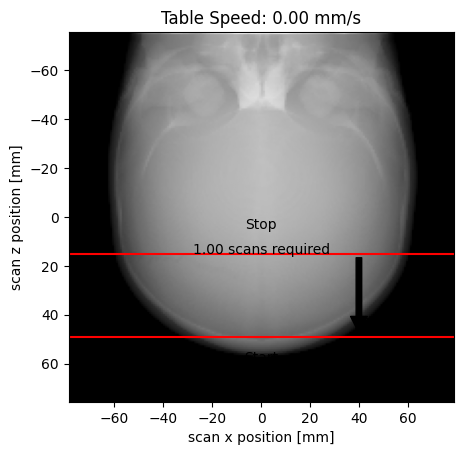

In [41]:
startZ, endZ = 15, 45
scanner.scout_view(startZ, endZ)

In [42]:
acquisition_technique = dict(
    mA=500,
    kVp=120,
    views=300,
    startZ=startZ,
    endZ=endZ,
    pitch=0
)
scanner.run_scan(**acquisition_technique)

scan: 1/1
Airscan
Offset scan
Phantom scan


  0%|          | 0/300 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of    132 MB.


100%|██████████| 300/300 [07:11<00:00,  1.44s/it]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.



        Scanner default_series
        Scanner: Siemens_DefinitionFlash
        Simulation Platform: CATSIM
        

fov size: 250
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...


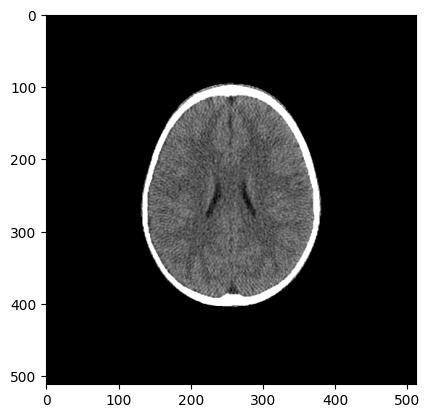

In [ ]:
recon_technique = dict(
    kernel='soft',
    fov=250,
    slice_increment=1,
)
scanner.run_recon(**recon_technique)

import matplotlib.pyplot as plt
ww, wl = 1000, 500
plt.imshow(scanner.recon[0], cmap='gray', vmin=wl-ww/2, vmax=wl+ww/2)

## Fracture Characteristics

Generate different fracture lengths and characteristics and insert into the same patient

In [44]:
fracture_lengths = np.linspace(0, 500, 3, dtype=int)
fracture_lengths

array([  0, 250, 500])

In [45]:
from insilicoICH.study import ICHStudy
import pandas as pd

single_study = ICHStudy.generate_from_distributions(
    ['6.5 yr NIHPD Head'],
    study_count=1,
    scanner_model=['Siemens_DefinitionFlash'],
    lesion_attenuation=dict(Fracture=[0, 1]),
    lesion_volume=dict(Fracture=[0, 1]), # placeholder for fractures to we better parameterize
    subtype=['Fracture'],
    output_directory = 'fracture_characteristics',
    fracture_length = [fracture_lengths[0], fracture_lengths[0] + 50],
    seed=42)
single_study

,case_id,phantom,scanner_model,kVp,mA,pitch,views,scan_coverage,recon_kernel,slice_thickness,...,output_directory,remove_raw,subtype,lesion_volume,lesion_attenuation,edema,age,mass_effect,fracture_length,add_augmentation
0,case_0000,6.5 yr NIHPD Head,Siemens_DefinitionFlash,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,/scratch/brandon.nelson/InSilicoICH/notebooks/...,True,Fracture,0.777778,0.434343,0,6.5,0.786878,4,True


In [46]:
study_list = [single_study]
for idx, length in enumerate(fracture_lengths[1:]):
    temp = single_study.copy()
    temp['fracture_length'] = length
    temp['case_id'] = f'case_{idx+1:04d}'
    temp['output_directory'] = single_study.output_directory.item().parent / f'case_{idx+1:04d}'
    study_list.append(temp)
study_list = pd.concat(study_list, ignore_index=True)
study = ICHStudy(study_list)
study.metadata

study plan saved to: /scratch/brandon.nelson/InSilicoICH/notebooks/study_plan.csv


,case_id,phantom,scanner_model,kVp,mA,pitch,views,scan_coverage,recon_kernel,slice_thickness,...,output_directory,remove_raw,subtype,lesion_volume,lesion_attenuation,edema,age,mass_effect,fracture_length,add_augmentation
0,case_0000,6.5 yr NIHPD Head,Siemens_DefinitionFlash,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,/scratch/brandon.nelson/InSilicoICH/notebooks/...,True,Fracture,0.777778,0.434343,0,6.5,0.786878,4,True
1,case_0001,6.5 yr NIHPD Head,Siemens_DefinitionFlash,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,/scratch/brandon.nelson/InSilicoICH/notebooks/...,True,Fracture,0.777778,0.434343,0,6.5,0.786878,250,True
2,case_0002,6.5 yr NIHPD Head,Siemens_DefinitionFlash,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,/scratch/brandon.nelson/InSilicoICH/notebooks/...,True,Fracture,0.777778,0.434343,0,6.5,0.786878,500,True


In [47]:
if not np.all(sorted(np.unique(study.results.get('case_id', []))) == study.metadata.case_id):
    study.run_all(parallel=True)

## Patient Characteristics

Demonstrate fracture generation on pediatric and adult patient subgroups by inserting the same fracture in all phantoms

In [49]:
from VITools import get_available_phantoms
get_available_phantoms()

{'0.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=0.0, phantom_dir=PosixPath('/projects01/didsr-aiml/common_data/pedsilicoich/UNC_Head_phantom')),
 '1.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=1.0, phantom_dir=PosixPath('/projects01/didsr-aiml/common_data/pedsilicoich/UNC_Head_phantom')),
 '2.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=2.0, phantom_dir=PosixPath('/projects01/didsr-aiml/common_data/pedsilicoich/UNC_Head_phantom')),
 '6.5 yr NIHPD Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.NIHPD_Head'>, age=6.5, phantom_dir=PosixPath('/projects01/didsr-aiml/common_data/pedsilicoich/NIHPD_Head_Phantom')),
 '9.0 yr NIHPD Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.NIHPD_Head'>, age=9.0, phantom_dir=PosixPath('/projects01/didsr-aiml/common_data/pedsilicoich/NIHPD_Head_Phantom')),
 '10.5 yr NIHPD He

In [50]:
phantoms = get_available_phantoms()
phantoms = [o for o in phantoms if o != 'Water Phantom']
phantoms = [o for o in phantoms if float(o.split(' yr')[0]) > 0] # age 0 phantom skull map not ready yet
phantoms

['1.0 yr UNC Head',
 '2.0 yr UNC Head',
 '6.5 yr NIHPD Head',
 '9.0 yr NIHPD Head',
 '10.5 yr NIHPD Head',
 '11.5 yr NIHPD Head',
 '12.0 yr NIHPD Head',
 '15.75 yr NIHPD Head',
 '38.0 yr MIDA Head']

In [51]:
single_study = ICHStudy.generate_from_distributions(
    [phantoms[0]],
    study_count=1,
    scanner_model=['Siemens_DefinitionFlash'],
    lesion_attenuation=dict(Fracture=[0, 1]),
    lesion_volume=dict(Fracture=[0, 1]), # placeholder for fractures to we better parameterize
    subtype=['Fracture'],
    output_directory = 'patient_characteristics',
    fracture_length = [150, 250],
    seed=42)
single_study

,case_id,phantom,scanner_model,kVp,mA,pitch,views,scan_coverage,recon_kernel,slice_thickness,...,output_directory,remove_raw,subtype,lesion_volume,lesion_attenuation,edema,age,mass_effect,fracture_length,add_augmentation
0,case_0000,1.0 yr UNC Head,Siemens_DefinitionFlash,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,/scratch/brandon.nelson/InSilicoICH/notebooks/...,True,Fracture,0.777778,0.434343,0,1.0,0.786878,158,True


In [52]:
study_list = [single_study]
for idx, phantom in enumerate(phantoms[1:]):
    temp = single_study.copy()
    temp['phantom'] = phantom
    temp['case_id'] = f'case_{idx+1:04d}'
    temp['output_directory'] = single_study.output_directory.item().parent / f'case_{idx+1:04d}'
    study_list.append(temp)
study_list = pd.concat(study_list, ignore_index=True)
study = ICHStudy(study_list)
study.metadata

study plan saved to: /scratch/brandon.nelson/InSilicoICH/notebooks/study_plan.csv


,case_id,phantom,scanner_model,kVp,mA,pitch,views,scan_coverage,recon_kernel,slice_thickness,...,output_directory,remove_raw,subtype,lesion_volume,lesion_attenuation,edema,age,mass_effect,fracture_length,add_augmentation
0,case_0000,1.0 yr UNC Head,Siemens_DefinitionFlash,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,/scratch/brandon.nelson/InSilicoICH/notebooks/...,True,Fracture,0.777778,0.434343,0,1.0,0.786878,158,True
1,case_0001,2.0 yr UNC Head,Siemens_DefinitionFlash,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,/scratch/brandon.nelson/InSilicoICH/notebooks/...,True,Fracture,0.777778,0.434343,0,1.0,0.786878,158,True
2,case_0002,6.5 yr NIHPD Head,Siemens_DefinitionFlash,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,/scratch/brandon.nelson/InSilicoICH/notebooks/...,True,Fracture,0.777778,0.434343,0,1.0,0.786878,158,True
3,case_0003,9.0 yr NIHPD Head,Siemens_DefinitionFlash,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,/scratch/brandon.nelson/InSilicoICH/notebooks/...,True,Fracture,0.777778,0.434343,0,1.0,0.786878,158,True
4,case_0004,10.5 yr NIHPD Head,Siemens_DefinitionFlash,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,/scratch/brandon.nelson/InSilicoICH/notebooks/...,True,Fracture,0.777778,0.434343,0,1.0,0.786878,158,True
5,case_0005,11.5 yr NIHPD Head,Siemens_DefinitionFlash,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,/scratch/brandon.nelson/InSilicoICH/notebooks/...,True,Fracture,0.777778,0.434343,0,1.0,0.786878,158,True
6,case_0006,12.0 yr NIHPD Head,Siemens_DefinitionFlash,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,/scratch/brandon.nelson/InSilicoICH/notebooks/...,True,Fracture,0.777778,0.434343,0,1.0,0.786878,158,True
7,case_0007,15.75 yr NIHPD Head,Siemens_DefinitionFlash,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,/scratch/brandon.nelson/InSilicoICH/notebooks/...,True,Fracture,0.777778,0.434343,0,1.0,0.786878,158,True
8,case_0008,38.0 yr MIDA Head,Siemens_DefinitionFlash,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,/scratch/brandon.nelson/InSilicoICH/notebooks/...,True,Fracture,0.777778,0.434343,0,1.0,0.786878,158,True


In [53]:
completed_studies = sorted(np.unique(study.results.get('case_id', [])))
len(completed_studies) == len(study.metadata.case_id)

True

In [54]:
completed_studies, study.metadata.case_id

(['case_0000',
  'case_0001',
  'case_0002',
  'case_0003',
  'case_0004',
  'case_0005',
  'case_0006',
  'case_0007',
  'case_0008'],
 0    case_0000
 1    case_0001
 2    case_0002
 3    case_0003
 4    case_0004
 5    case_0005
 6    case_0006
 7    case_0007
 8    case_0008
 Name: case_id, dtype: object)

In [55]:
np.all(sorted(np.unique(study.results.get('case_id', []))) == study.metadata.case_id)

np.True_

In [56]:
study.run_all(parallel=True)

Running 9 simulation conditions
See logs at /scratch/brandon.nelson/InSilicoICH/notebooks/patient_characteristics/logs/VIT-BATCH_11-06-2025_11-47
10448490


Scans completed in parallel: 0it [00:00, ?it/s]



Input metadata:

     case_id              phantom            scanner_model    kVp     mA  \
0  case_0000      1.0 yr UNC Head  Siemens_DefinitionFlash  120.0  300.0   
1  case_0001      2.0 yr UNC Head  Siemens_DefinitionFlash  120.0  300.0   
2  case_0002    6.5 yr NIHPD Head  Siemens_DefinitionFlash  120.0  300.0   
3  case_0003    9.0 yr NIHPD Head  Siemens_DefinitionFlash  120.0  300.0   
4  case_0004   10.5 yr NIHPD Head  Siemens_DefinitionFlash  120.0  300.0   
5  case_0005   11.5 yr NIHPD Head  Siemens_DefinitionFlash  120.0  300.0   
6  case_0006   12.0 yr NIHPD Head  Siemens_DefinitionFlash  120.0  300.0   
7  case_0007  15.75 yr NIHPD Head  Siemens_DefinitionFlash  120.0  300.0   
8  case_0008    38.0 yr MIDA Head  Siemens_DefinitionFlash  120.0  300.0   

   pitch   views scan_coverage recon_kernel  slice_thickness  ...  \
0    0.0  1000.0       dynamic         soft                1  ...   
1    0.0  1000.0       dynamic         soft                1  ...   
2    0.0  1000

In [57]:
from tqdm import tqdm
recons = []
masks = []
ages = []
for case in study.metadata.case_id.unique():
    idx = int(case.split('case_')[1])
    ages.append(study.metadata[study.metadata.case_id == case].age.iloc[0])
    recons.append(study.get_images(idx))
    masks.append(study.get_masks(idx))

## Impact of Reconstruction Kernel

Reconstruction kernels control the balance of noise and image sharpness in CT, bone kernels are typically sharper to accentuate high frequency details necesarry for fracture detection. Here we illustrate the impact of kernel selection on fracture visibility.

In [59]:
kernels = ['bone', 'standard', 'soft']

recons = []
for kernel in kernels:
    scanner.run_recon(slice_thickness=1, kernel=kernel)
    recons.append(scanner.recon)

fov size: 250
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...
fov size: 250
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...
fov size: 250
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a n

In [60]:
from insilicoICH.study import MaskHandler

handler = MaskHandler(scanner)
handler.get_lesion_mask()

Initializing Scanner object...
----------
* Calculating volume fraction maps for 2 materials and 189 slices...
* Writing volume fraction files for 2 materials and 189 slices, plus HU data...
* Writing /tmp/tmpqi4caeiv/6.5 yr NIHPD Head/lesion_mask/lesion only/phantoms/0/0_ICRU_lung_adult_healthy_197x233x189.raw...
* Writing /tmp/tmpqi4caeiv/6.5 yr NIHPD Head/lesion_mask/lesion only/phantoms/0/0_water_197x233x189.raw...
* Writing /tmp/tmpqi4caeiv/6.5 yr NIHPD Head/lesion_mask/lesion only/phantoms/0/0_HU_data_197x233x189.raw...
* Writing /tmp/tmpqi4caeiv/6.5 yr NIHPD Head/lesion_mask/lesion only/phantoms/0/0.json...
Scanner Ready
scan: 1/1
Airscan
Offset scan
Phantom scan


  0%|          | 0/300 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated a total of     66 MB.


100%|██████████| 300/300 [02:52<00:00,  1.74it/s]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.


AttributeError: 'Scanner' object has no attribute 'slice_thickness'

In [ ]:
segmentations = handler.get_segmentation_mask()

In [ ]:
from utils import ctshow, center_crop
f, axs = plt.subplots(1, len(recons), gridspec_kw=dict(wspace=0, hspace=0), dpi=300)
z = segmentations.sum(axis=(1,2)).argmax()
for ax, recon, kernel in zip(axs.flatten(), recons, kernels):
    x1, x2 = (110, 220)
    y1, y2 = (140, 260)
    ctshow(recon[z][y1:y2, x1:x2], (1000, 400), fig=f, ax=ax)
    lesion_mask = handler.lesion_ids[0]['mask']
    lesion_roi = recon[lesion_mask]
    mean = lesion_roi.mean()
    std = lesion_roi.std()
    ax.set_title(f'{kernel}')
    # ax.set_title(f'{kernel}\nmean, std: {mean:2.1f}, {std:2.1f} HU', fontsize=6)